In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_spec_espace(filename):
    data = np.loadtxt(filename, comments = "#").T
    data = np.asarray([data[1], data[3]])
    data = np.transpose(data)
    data = pd.DataFrame(data)
    return data

def load_spec_kspace(filename):
    data = np.loadtxt(filename, comments = "#").T
    data = np.asarray([data[2], data[5]])
    data = np.transpose(data)
    data = pd.DataFrame(data)
    return data

In [41]:
dats=[]
for file in os.listdir():
    if 'mn7o12' in file:
        dats.append(file)

In [42]:
dats

['xmu_mn7o12_mn0_xes.dat',
 'xmu_mn7o12_mn8_xanes.dat',
 'xmu_mn7o12_mn8_exafs.dat',
 'xmu_mn7o12_mn0_xanes.dat',
 'xmu_mn7o12_mn8_xes.dat',
 'xmu_mn7o12_mn0_exafs.dat']

In [43]:
xanes = []
xes = []
exafs = []
for file in dats:
    if 'xanes' in file:
        xanes.append(file)
    if 'xes' in file:
        xes.append(file)
    if 'exafs' in file:
        exafs.append(file)

xanes_df = []
xes_df = []
exafs_e_df = []
exafs_k_df = []
for file in xanes:
    df = load_spec_espace(file)
    xanes_df.append(df)
for file in xes:
    df = load_spec_espace(file)
    xes_df.append(df)
for file in exafs:
    df1 = load_spec_espace(file)
    exafs_e_df.append(df1)
    df2 = load_spec_kspace(file)
    exafs_k_df.append(df2)

In [56]:
xanes

['xmu_mn2o7_mn12_xanes.dat',
 'xmu_mn2o7_mn8_xanes.dat',
 'xmu_mn2o7_mn4_xanes.dat',
 'xmu_mn2o7_mn0_xanes.dat']

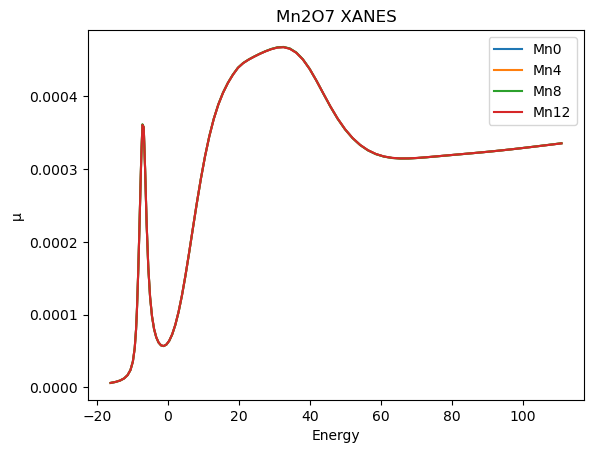

In [57]:
plt.plot(xanes_df[3][0],xanes_df[3][1], label='Mn0')
plt.plot(xanes_df[2][0],xanes_df[2][1], label='Mn4')
plt.plot(xanes_df[1][0],xanes_df[1][1], label='Mn8')
plt.plot(xanes_df[0][0],xanes_df[0][1], label='Mn12')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Mn2O7 XANES')
plt.legend()
plt.show()

In [58]:
xes

['xmu_mn2o7_mn8_xes.dat',
 'xmu_mn2o7_mn4_xes.dat',
 'xmu_mn2o7_mn12_xes.dat',
 'xmu_mn2o7_mn0_xes.dat']

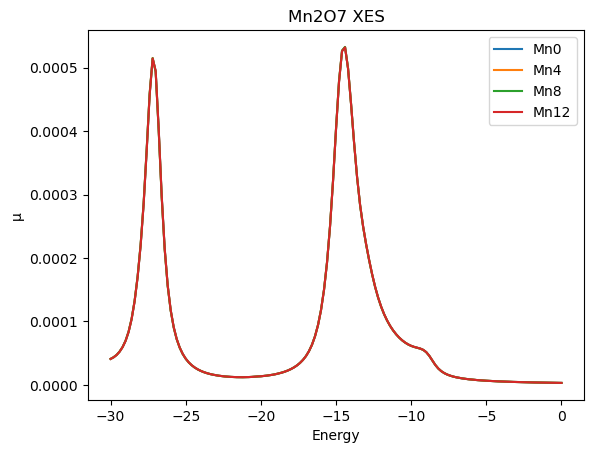

In [59]:
plt.plot(xes_df[3][0],xes_df[3][1], label='Mn0')
plt.plot(xes_df[1][0],xes_df[1][1], label='Mn4')
plt.plot(xes_df[0][0],xes_df[0][1], label='Mn8')
plt.plot(xes_df[2][0],xes_df[2][1], label='Mn12')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Mn2O7 XES')
plt.legend()
plt.show()

In [44]:
exafs

['xmu_mn7o12_mn8_exafs.dat', 'xmu_mn7o12_mn0_exafs.dat']

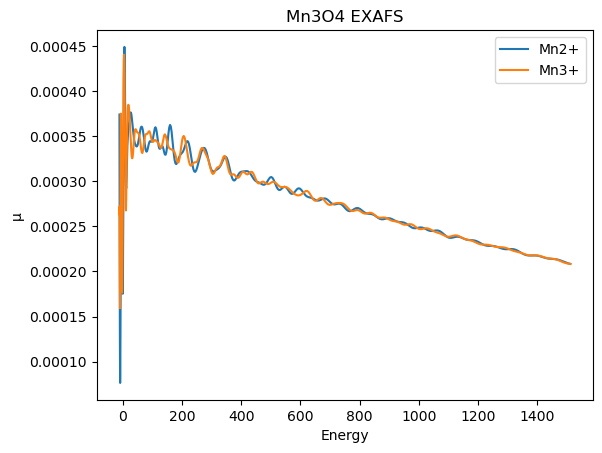

In [12]:
plt.plot(exafs_e_df[0][0],exafs_e_df[0][1], label='Mn2+')
plt.plot(exafs_e_df[1][0],exafs_e_df[1][1], label='Mn3+')
plt.xlabel('Energy')
plt.ylabel('μ')
plt.title('Mn3O4 EXAFS')
plt.legend()
plt.show()

In [45]:
#Make df of k vs k^2 chi

exafs_k2_df = []
for df in exafs_k_df:
    df[2] = df[1]*df[0]**2
    exafs_k2_df.append(df)

print(exafs_k2_df[0])


         0         1         2
0     0.00  1.681570  0.000000
1     0.05  1.672130  0.004180
2     0.10  1.660330  0.016603
3     0.15  1.616370  0.036368
4     0.20  1.554760  0.062190
..     ...       ...       ...
396  19.80 -0.007772 -3.046958
397  19.85 -0.007550 -2.974992
398  19.90 -0.006324 -2.504252
399  19.95 -0.004886 -1.944831
400  20.00 -0.003731 -1.492572

[401 rows x 3 columns]


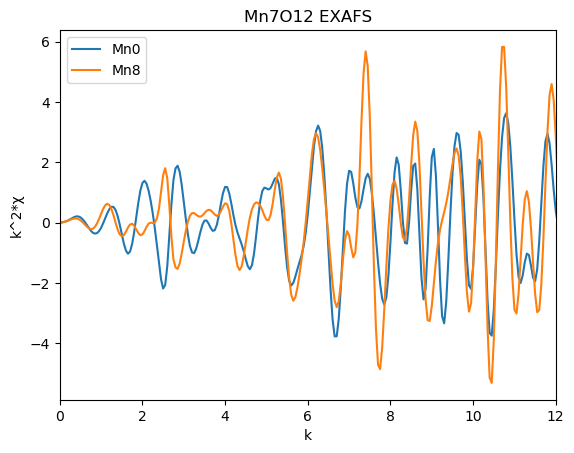

In [47]:
plt.plot(exafs_k2_df[1][0],exafs_k2_df[1][2], label='Mn0')
plt.plot(exafs_k2_df[0][0],exafs_k2_df[0][2], label='Mn8')
plt.xlim(0,12)
plt.xlabel('k')
plt.ylabel('k^2*χ')
plt.title('Mn7O12 EXAFS')
plt.legend()
plt.show()

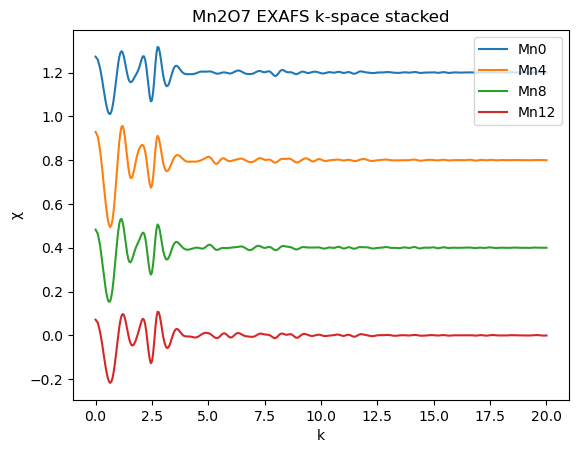

In [64]:
plt.plot(exafs_k_df[0][0],exafs_k_df[0][1]+1.2, label='Mn0')
plt.plot(exafs_k_df[2][0],exafs_k_df[2][1]+0.8, label='Mn4')
plt.plot(exafs_k_df[3][0],exafs_k_df[3][1]+0.4, label='Mn8')
plt.plot(exafs_k_df[1][0],exafs_k_df[1][1], label='Mn12')
plt.xlabel('k')
plt.ylabel('χ')
plt.title('Mn2O7 EXAFS k-space stacked')
plt.legend()
plt.show()